In [1]:
#use of pandas for manipulation ,numpy for data generation and matplotlib/seaborn for visualization 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
#generating a dummy dataset 
#Creating a bank dataset with missing values and duplicates 
data = {'Customer_ID':[101,102,103,104,105,101,106,107,108,109],
        'Age':[25,34,np.nan,45,23,25,52,np.nan,39,30],
        'Balance':[2500,5000,1200,8000,np.nan,2500,15000,3200,np.nan,4100],
        'Account_Type':['Savings','Checking','Savings','Checking','Savings','Savings','Investment','Savings','Checking','Investment'],
        'Region':['North','South','East','West','North','North','South','West','East','South']}
Banc_XYZ=pd.DataFrame(data)
Banc_XYZ

,Customer_ID,Age,Balance,Account_Type,Region
0,101,25.0,2500.0,Savings,North
1,102,34.0,5000.0,Checking,South
2,103,NaN,1200.0,Savings,East
3,104,45.0,8000.0,Checking,West
4,105,23.0,NaN,Savings,North
5,101,25.0,2500.0,Savings,North
6,106,52.0,15000.0,Investment,South
7,107,NaN,3200.0,Savings,West
8,108,39.0,NaN,Checking,East
9,109,30.0,4100.0,Investment,South


In [3]:
#data cleaning part 1 : de-duplication
#removing duplicate row for Customer 101
Banc_XYZ=Banc_XYZ.drop_duplicates ().reset_index(drop=True)
Banc_XYZ

,Customer_ID,Age,Balance,Account_Type,Region
0,101,25.0,2500.0,Savings,North
1,102,34.0,5000.0,Checking,South
2,103,NaN,1200.0,Savings,East
3,104,45.0,8000.0,Checking,West
4,105,23.0,NaN,Savings,North
5,106,52.0,15000.0,Investment,South
6,107,NaN,3200.0,Savings,West
7,108,39.0,NaN,Checking,East
8,109,30.0,4100.0,Investment,South


In [4]:
#data_cleaning part 2:handling missing values
#filling Age with the median and Balance with the mean
Banc_XYZ['Age']=Banc_XYZ['Age'].fillna(Banc_XYZ['Age'].median())
Banc_XYZ['Balance']=Banc_XYZ['Balance'].fillna(Banc_XYZ['Balance'].mean())
Banc_XYZ['Balance']=Banc_XYZ['Balance'].round(2)
Banc_XYZ

,Customer_ID,Age,Balance,Account_Type,Region
0,101,25.0,2500.00,Savings,North
1,102,34.0,5000.00,Checking,South
2,103,34.0,1200.00,Savings,East
3,104,45.0,8000.00,Checking,West
4,105,23.0,5571.43,Savings,North
5,106,52.0,15000.00,Investment,South
6,107,34.0,3200.00,Savings,West
7,108,39.0,5571.43,Checking,East
8,109,30.0,4100.00,Investment,South


In [5]:
#Z-Scores & Normalization
# Formula for Z-score: z = (x - μ) / σ
Banc_XYZ['Balance_ZScore'] = (Banc_XYZ['Balance'] - Banc_XYZ['Balance'].mean()) / Banc_XYZ['Balance'].std()
Banc_XYZ

,Customer_ID,Age,Balance,Account_Type,Region,Balance_ZScore
0,101,25.0,2500.00,Savings,North,-7.577014e-01
1,102,34.0,5000.00,Checking,South,-1.409678e-01
2,103,34.0,1200.00,Savings,East,-1.078403e+00
3,104,45.0,8000.00,Checking,West,5.991126e-01
4,105,23.0,5571.43,Savings,North,2.741038e-07
5,106,52.0,15000.00,Investment,South,2.325967e+00
6,107,34.0,3200.00,Savings,West,-5.850160e-01
7,108,39.0,5571.43,Checking,East,2.741038e-07
8,109,30.0,4100.00,Investment,South,-3.629919e-01


In [6]:
#Min-Max Scaling (Normalising data to a 0-1 range)
#formula :x_scaled  = (x-x_min)/(x_max-x_min)
b_min,b_max = Banc_XYZ['Balance'].min(),Banc_XYZ['Balance'].max()
Banc_XYZ['Balance_Normalized'] = (Banc_XYZ['Balance']-b_min)/(b_max-b_min)
Banc_XYZ

,Customer_ID,Age,Balance,Account_Type,Region,Balance_ZScore,Balance_Normalized
0,101,25.0,2500.00,Savings,North,-7.577014e-01,0.094203
1,102,34.0,5000.00,Checking,South,-1.409678e-01,0.275362
2,103,34.0,1200.00,Savings,East,-1.078403e+00,0.000000
3,104,45.0,8000.00,Checking,West,5.991126e-01,0.492754
4,105,23.0,5571.43,Savings,North,2.741038e-07,0.316770
5,106,52.0,15000.00,Investment,South,2.325967e+00,1.000000
6,107,34.0,3200.00,Savings,West,-5.850160e-01,0.144928
7,108,39.0,5571.43,Checking,East,2.741038e-07,0.316770
8,109,30.0,4100.00,Investment,South,-3.629919e-01,0.210145


In [7]:
#Subsetting with loc and iloc
#Idebtifying Outliers :Values with a z_score >2 (statistical significance)
outliers = Banc_XYZ.loc[Banc_XYZ['Balance_ZScore'].abs()>2 ]
Banc_XYZsubset_view = Banc_XYZ.iloc[0:5,[0,2,5,6]]
Banc_XYZsubset_view 

,Customer_ID,Balance,Balance_ZScore,Balance_Normalized
0,101,2500.00,-7.577014e-01,0.094203
1,102,5000.00,-1.409678e-01,0.275362
2,103,1200.00,-1.078403e+00,0.000000
3,104,8000.00,5.991126e-01,0.492754
4,105,5571.43,2.741038e-07,0.316770


In [8]:
#Grouping and Aggregation
#Statistical summary per Region 
regional_stats =Banc_XYZ.groupby('Region')['Balance'].agg(['mean','std','var']).reset_index()
regional_stats

,Region,mean,std,var
0,East,3385.715000,3091.067796,9.554700e+06
1,North,4035.715000,2171.828981,4.716841e+06
2,South,8033.333333,6050.068870,3.660333e+07
3,West,5600.000000,3394.112550,1.152000e+07


In [9]:
#adding a new metric ,creating a 'Risk-level' column based on balance 
Banc_XYZ['High_Value_Flag']=Banc_XYZ['Balance'].apply(lambda x :'High'if x> 8000 else ('Low' if x< 5000 else 'Standard'))
Banc_XYZ

,Customer_ID,Age,Balance,Account_Type,Region,Balance_ZScore,Balance_Normalized,High_Value_Flag
0,101,25.0,2500.00,Savings,North,-7.577014e-01,0.094203,Low
1,102,34.0,5000.00,Checking,South,-1.409678e-01,0.275362,Standard
2,103,34.0,1200.00,Savings,East,-1.078403e+00,0.000000,Low
3,104,45.0,8000.00,Checking,West,5.991126e-01,0.492754,Standard
4,105,23.0,5571.43,Savings,North,2.741038e-07,0.316770,Standard
5,106,52.0,15000.00,Investment,South,2.325967e+00,1.000000,High
6,107,34.0,3200.00,Savings,West,-5.850160e-01,0.144928,Low
7,108,39.0,5571.43,Checking,East,2.741038e-07,0.316770,Standard
8,109,30.0,4100.00,Investment,South,-3.629919e-01,0.210145,Low


In [10]:
#Groupimg & Aggregation , finding the average balance per Account type 
branch_summary = Banc_XYZ.groupby('Account_Type')['Balance'].agg(['mean','sum','median']).reset_index().round(2)
branch_summary

,Account_Type,mean,sum,median
0,Checking,6190.48,18571.43,5571.43
1,Investment,9550.00,19100.00,9550.00
2,Savings,3117.86,12471.43,2850.00


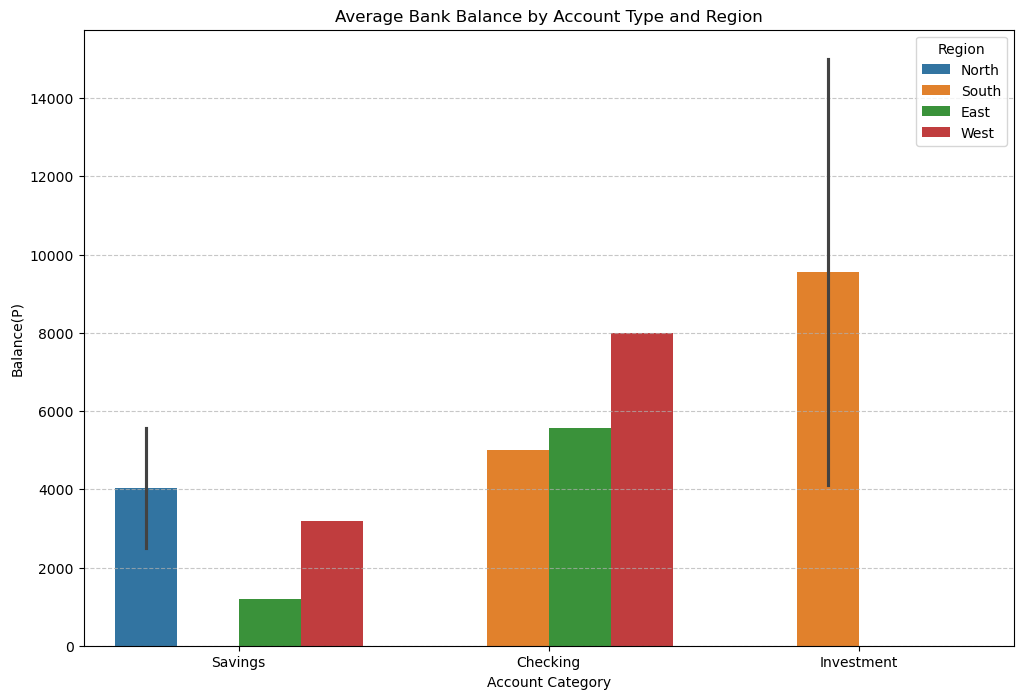

In [11]:
#Visualization part 1 
plt.figure(figsize=(12,8))
sns.barplot(data=Banc_XYZ,x='Account_Type',y='Balance',hue='Region')
plt.title('Average Bank Balance by Account Type and Region')
plt.xlabel('Account Category')
plt.ylabel('Balance(P)')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()



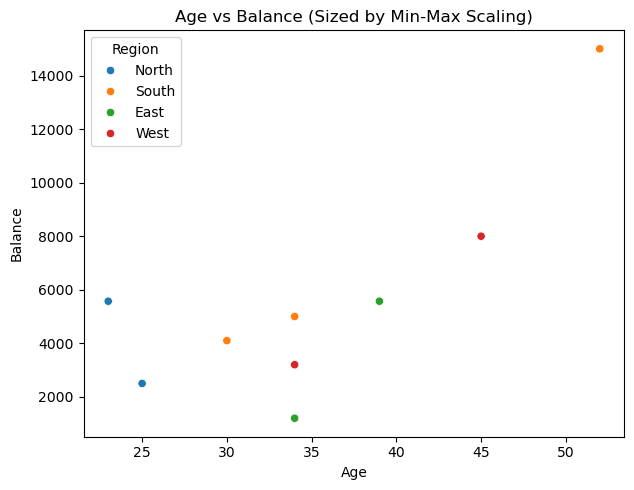

In [12]:
#Visualization part 2
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
sns.scatterplot(data=Banc_XYZ, x='Age', y='Balance', hue='Region')
plt.title('Age vs Balance (Sized by Min-Max Scaling)')
plt.tight_layout()
plt.show()